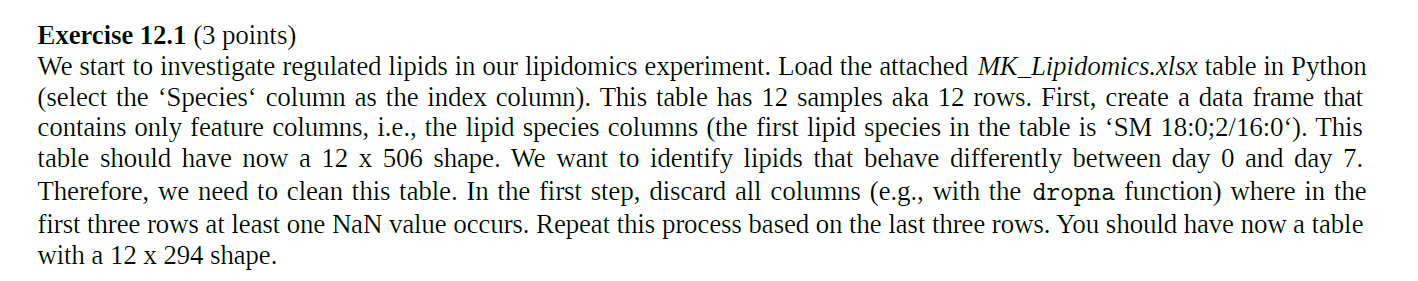

In [ ]:
import pandas as pd

# Load the data from the provided path
df = pd.read_excel('MK_Lipidomics.xlsx', index_col='Species')

# Select only lipid species columns, starting from 'SM 18:0;2/16:0'
features = df.loc[:, 'SM 18:0;2/16:0':]

# Drop columns with NaNs in the first 3 rows
clean1 = features.dropna(axis=1, how='any', subset=features.index[:3])

# Drop columns with NaNs in the last 3 rows
clean2 = clean1.dropna(axis=1, how='any', subset=clean1.index[-3:])

# Print the shapes at each step
print("Original (with features):", features.shape)
print("After dropping NaNs in first 3 rows:", clean1.shape)
print("After dropping NaNs in last 3 rows:", clean2.shape)


Original (with features): (12, 506)
After dropping NaNs in first 3 rows: (12, 325)
After dropping NaNs in last 3 rows: (12, 294)


In [ ]:
import pandas as pd
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

# (re)load and clean exactly as before to get your final 12×294 DataFrame:
df      = pd.read_excel("MK_Lipidomics.xlsx", index_col="Species")
features= df.loc[:, "SM 18:0;2/16:0":]
clean1  = features.dropna(axis=1, how="any", subset=features.index[:3])
clean2  = clean1 .dropna(axis=1, how="any", subset=clean1.index[-3:])

# Split into day 0 (first 3) and day 7 (last 3)
day0 = clean2.iloc[:3, :]
day7 = clean2.iloc[-3:, :]

# 1) two‐sided Welch’s t-test across each column (lipid)
t_stats, p_vals = ttest_ind(day0, day7,
                            axis=0,
                            equal_var=False)

# 2) Benjamini–Hochberg correction
_, p_adj, _, _ = multipletests(p_vals,
                                alpha=0.05,
                                method="fdr_bh")

# 3) assemble results into a DataFrame
results = pd.DataFrame({
    "t_statistic": t_stats,
    "p_value":     p_vals,
    "p_adj_BH":    p_adj
}, index=clean2.columns)

# Quick look at the top hits
print(results.sort_values("p_adj_BH").head(10))


                t_statistic   p_value  p_adj_BH
PG 16:0_18:1     -50.839580  0.000004  0.001200
LPI 18:1         -24.308361  0.000017  0.001939
PG 16:1_18:1     -45.431878  0.000020  0.001939
SM 18:0;2/22:0   -24.921084  0.000042  0.003080
PC 16:1_18:2     -14.315715  0.000149  0.003371
PC 16:1_16:1    -103.044261  0.000086  0.003371
PG 16:0_16:0     -21.746987  0.000142  0.003371
PA 16:0_18:1     -20.581235  0.000092  0.003371
PE 16:0_18:1     -26.728404  0.000094  0.003371
PE 18:0_22:3     -31.887275  0.000122  0.003371


In [ ]:
import pandas as pd
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

# Load and clean as before
df = pd.read_excel('MK_Lipidomics.xlsx', index_col='Species')
features = df.loc[:, 'SM 18:0;2/16:0':]
clean1 = features.dropna(axis=1, how='any', subset=features.index[:3])
clean2 = clean1.dropna(axis=1, how='any', subset=clean1.index[-3:])

# Split into day 0 and day 7
day0 = clean2.iloc[:3, :]
day7 = clean2.iloc[-3:, :]

# Welch's t-test
t_stats, p_vals = ttest_ind(day0, day7, axis=0, equal_var=False)

# Benjamini-Hochberg correction
_, p_adj, _, _ = multipletests(p_vals, alpha=0.05, method='fdr_bh')

# Assemble results
results = pd.DataFrame({
    't_statistic': t_stats,
    'p_value':     p_vals,
    'p_adj_BH':    p_adj
}, index=clean2.columns)

# Filter significant lipids
sig = results[results['p_adj_BH'] < 0.05]

# Display count and full list
print(f"Number of lipids with adjusted p < 0.05: {sig.shape[0]}")
print("Significant lipids (FDR < 0.05)", sig)


Number of lipids with adjusted p < 0.05: 200
Significant lipids (FDR < 0.05)                 t_statistic   p_value  p_adj_BH
SM 18:0;2/20:0    -4.973413  0.033354  0.049777
SM 18:0;2/22:0   -24.921084  0.000042  0.003080
SM 18:0;2/24:0   -70.849950  0.000088  0.003371
SM 18:0;2/24:1    -5.377691  0.016037  0.031432
SM 18:1;2/16:0    -4.812152  0.009618  0.024377
...                     ...       ...       ...
SE 27:1/16:1      -6.132699  0.005805  0.018551
SE 27:1/18:0      -6.656636  0.018845  0.033990
SE 27:1/18:1      -6.366170  0.023652  0.039510
SE 27:1/20:4      -4.082782  0.015218  0.030435
SE 27:1/22:6      -6.131239  0.021480  0.036930

[200 rows x 3 columns]


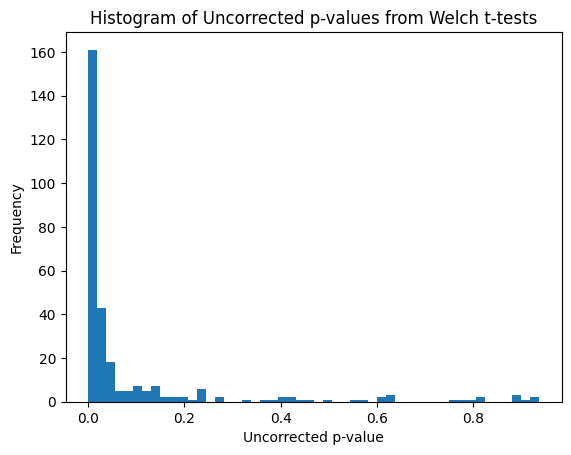

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# Load and clean as before
df = pd.read_excel('MK_Lipidomics.xlsx', index_col='Species')
features = df.loc[:, 'SM 18:0;2/16:0':]
clean1 = features.dropna(axis=1, how='any', subset=features.index[:3])
clean2 = clean1.dropna(axis=1, how='any', subset=clean1.index[-3:])

# Split into day 0 and day 7
day0 = clean2.iloc[:3, :]
day7 = clean2.iloc[-3:, :]

# Compute uncorrected p-values via Welch's t-test
_, p_vals = ttest_ind(day0, day7, axis=0, equal_var=False)

# Plot histogram
plt.figure()
plt.hist(p_vals, bins=50)
plt.xlabel('Uncorrected p-value')
plt.ylabel('Frequency')
plt.title('Histogram of Uncorrected p-values from Welch t-tests')
plt.show()
